# ID/X Partners Data Scientist

In [1]:
!gdown --id 1sL2joWOAlk4DkhDFNmrs7DnlqpO8mVeO

/usr/local/lib/python3.13/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1sL2joWOAlk4DkhDFNmrs7DnlqpO8mVeO
From (redirected): https://drive.google.com/uc?id=1sL2joWOAlk4DkhDFNmrs7DnlqpO8mVeO&confirm=t&uuid=e2a47ed7-a0af-4e8e-821c-a21bfa3834b1
To: /content/loan_data_2007_2014.csv
100% 240M/240M [00:06<00:00, 39.8MB/s]


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,  precision_score, recall_score, f1_score, roc_auc_score

In [4]:
df = pd.read_csv('/content/loan_data_2007_2014.csv')
df.drop('Unnamed: 0', axis=1, inplace=True)
df.tail()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
466280,8598660,1440975,18400,18400,18400.0,60 months,14.47,432.64,C,C2,...,NaN,NaN,NaN,NaN,NaN,NaN,29900.0,NaN,NaN,NaN
466281,9684700,11536848,22000,22000,22000.0,60 months,19.97,582.50,D,D5,...,NaN,NaN,NaN,NaN,NaN,NaN,39400.0,NaN,NaN,NaN
466282,9584776,11436914,20700,20700,20700.0,60 months,16.99,514.34,D,D1,...,NaN,NaN,NaN,NaN,NaN,NaN,13100.0,NaN,NaN,NaN
466283,9604874,11457002,2000,2000,2000.0,36 months,7.90,62.59,A,A4,...,NaN,NaN,NaN,NaN,NaN,NaN,53100.0,NaN,NaN,NaN
466284,9199665,11061576,10000,10000,9975.0,36 months,19.20,367.58,D,D3,...,NaN,NaN,NaN,NaN,NaN,NaN,16000.0,NaN,NaN,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 74 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           466285 non-null  int64  
 1   member_id                    466285 non-null  int64  
 2   loan_amnt                    466285 non-null  int64  
 3   funded_amnt                  466285 non-null  int64  
 4   funded_amnt_inv              466285 non-null  float64
 5   term                         466285 non-null  object 
 6   int_rate                     466285 non-null  float64
 7   installment                  466285 non-null  float64
 8   grade                        466285 non-null  object 
 9   sub_grade                    466285 non-null  object 
 10  emp_title                    438697 non-null  object 
 11  emp_length                   445277 non-null  object 
 12  home_ownership               466285 non-null  object 
 13 

In [6]:
missing_columns_count = (df.isnull().sum() > 0).sum()
print(f"Jumlah kolom yang memiliki missing value: {missing_columns_count}")

Jumlah kolom yang memiliki missing value: 40


In [7]:
# 1. Melihat daftar kolom numerik
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("Kolom Numerik:", list(numerical_cols))
print("Jumlah kolom numerik:", len(numerical_cols))

# 2. Melihat daftar kolom kategorikal
categorical_cols = df.select_dtypes(include=['object']).columns
print("\nKolom Kategorikal:", list(categorical_cols))
print("Jumlah kolom kategorikal:", len(categorical_cols))

Kolom Numerik: ['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'int_rate', 'installment', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_amnt', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m', 'open_il_6m', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util', 'total_rev_hi_lim', 'inq_fi', 'total_cu_tl', 'inq_last_12m']
Jumlah kolom numerik: 52

Kolom Kategorikal: ['term', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'verifi

# Missing Value

In [8]:
df.isnull().sum()

,0
id,0
member_id,0
loan_amnt,0
funded_amnt,0
funded_amnt_inv,0
...,...
all_util,466285
total_rev_hi_lim,70276
inq_fi,466285
total_cu_tl,466285


In [9]:
df = df.dropna(axis=1, how='all')

In [10]:
threshold = len(df) * 0.6
df = df.dropna(thresh=threshold, axis=1)

In [11]:
df.isnull().sum()

,0
id,0
member_id,0
loan_amnt,0
funded_amnt,0
funded_amnt_inv,0
term,0
int_rate,0
installment,0
grade,0
sub_grade,0


In [12]:
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

In [13]:
for col in df.select_dtypes(include=['object']).columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 52 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   id                          466285 non-null  int64  
 1   member_id                   466285 non-null  int64  
 2   loan_amnt                   466285 non-null  int64  
 3   funded_amnt                 466285 non-null  int64  
 4   funded_amnt_inv             466285 non-null  float64
 5   term                        466285 non-null  object 
 6   int_rate                    466285 non-null  float64
 7   installment                 466285 non-null  float64
 8   grade                       466285 non-null  object 
 9   sub_grade                   466285 non-null  object 
 10  emp_title                   466285 non-null  object 
 11  emp_length                  466285 non-null  object 
 12  home_ownership              466285 non-null  object 
 13  annual_inc    

In [15]:
df.isnull().sum()

,0
id,0
member_id,0
loan_amnt,0
funded_amnt,0
funded_amnt_inv,0
term,0
int_rate,0
installment,0
grade,0
sub_grade,0


# Duplicate Data

In [16]:
df.duplicated().sum()

np.int64(0)

# Statistical Analysis

In [17]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,466285.0,1.307973e+07,1.089371e+07,54734.00,3.639987e+06,1.010790e+07,2.073121e+07,3.809811e+07
member_id,466285.0,1.459766e+07,1.168237e+07,70473.00,4.379705e+06,1.194108e+07,2.300154e+07,4.086083e+07
loan_amnt,466285.0,1.431728e+04,8.286509e+03,500.00,8.000000e+03,1.200000e+04,2.000000e+04,3.500000e+04
funded_amnt,466285.0,1.429180e+04,8.274371e+03,500.00,8.000000e+03,1.200000e+04,2.000000e+04,3.500000e+04
funded_amnt_inv,466285.0,1.422233e+04,8.297638e+03,0.00,8.000000e+03,1.200000e+04,1.995000e+04,3.500000e+04
int_rate,466285.0,1.382924e+01,4.357587e+00,5.42,1.099000e+01,1.366000e+01,1.649000e+01,2.606000e+01
installment,466285.0,4.320612e+02,2.434855e+02,15.67,2.566900e+02,3.798900e+02,5.665800e+02,1.409990e+03
annual_inc,466285.0,7.327729e+04,5.496334e+04,1896.00,4.500000e+04,6.300000e+04,8.895300e+04,7.500000e+06
dti,466285.0,1.721876e+01,7.851121e+00,0.00,1.136000e+01,1.687000e+01,2.278000e+01,3.999000e+01
delinq_2yrs,466285.0,2.846607e-01,7.973435e-01,0.00,0.000000e+00,0.000000e+00,0.000000e+00,2.900000e+01


In [18]:
display(df.select_dtypes(include=['object']).describe().T)

,count,unique,top,freq
term,466285,2,36 months,337953
grade,466285,7,B,136929
sub_grade,466285,35,B3,31686
emp_title,466285,205475,Teacher,32987
emp_length,466285,11,10+ years,171057
home_ownership,466285,6,MORTGAGE,235875
verification_status,466285,3,Verified,168055
issue_d,466285,91,Oct-14,38782
loan_status,466285,9,Current,224226
pymnt_plan,466285,2,n,466276


# Univariate Analysis

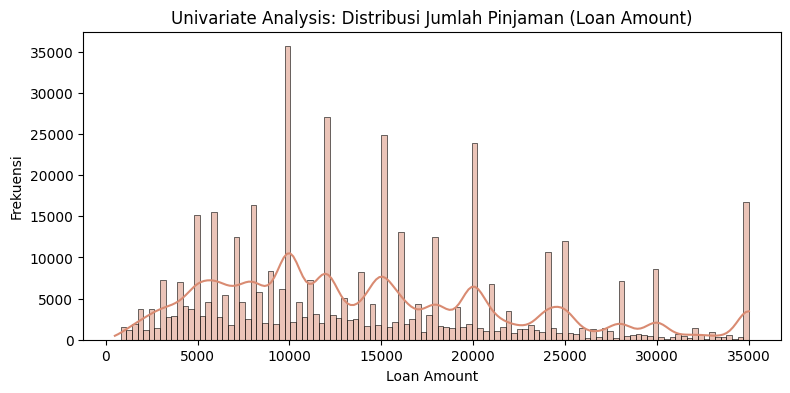

In [77]:
plt.figure(figsize=(9, 4))
sns.histplot(df['loan_amnt'], kde=True, color='#d98b72')
plt.title('Univariate Analysis: Distribusi Jumlah Pinjaman (Loan Amount)')
plt.xlabel('Loan Amount')
plt.ylabel('Frekuensi')
plt.show()

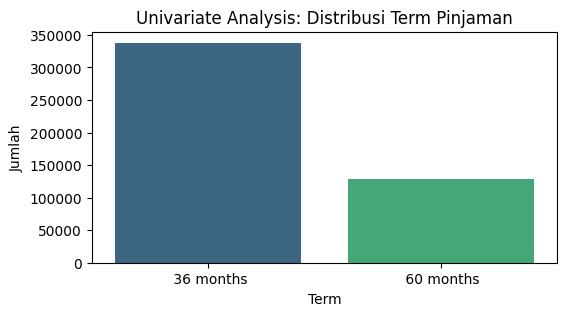

In [20]:
plt.figure(figsize=(6, 3))
sns.countplot(x='term', data=df, palette='viridis')
plt.title('Univariate Analysis: Distribusi Term Pinjaman')
plt.xlabel('Term')
plt.ylabel('Jumlah')
plt.show()

# Bivariate Analysis

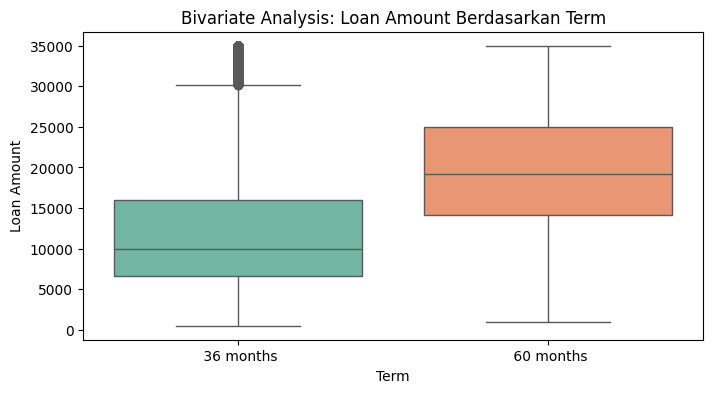

In [21]:
plt.figure(figsize=(8, 4))
sns.boxplot(x='term', y='loan_amnt', data=df, palette='Set2')
plt.title('Bivariate Analysis: Loan Amount Berdasarkan Term')
plt.xlabel('Term')
plt.ylabel('Loan Amount')
plt.show()

# Multivariate Analysis

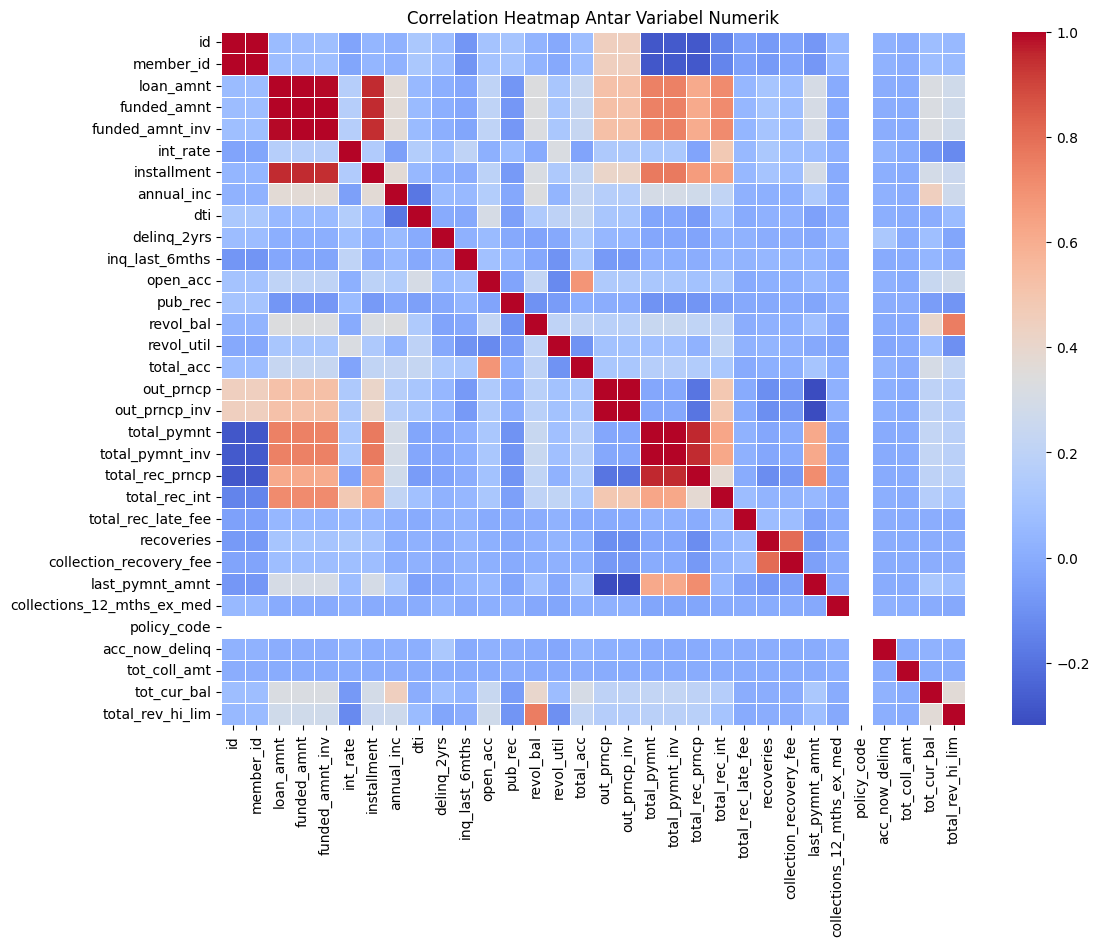

In [22]:
plt.figure(figsize=(12, 9))
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
correlation_matrix = df[numeric_cols].corr()

sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap Antar Variabel Numerik')
plt.show()

In [23]:
print(df['loan_status'].value_counts())

loan_status
Current                                                224226
Fully Paid                                             184739
Charged Off                                             42475
Late (31-120 days)                                       6900
In Grace Period                                          3146
Does not meet the credit policy. Status:Fully Paid       1988
Late (16-30 days)                                        1218
Default                                                   832
Does not meet the credit policy. Status:Charged Off       761
Name: count, dtype: int64


In [24]:
def map_loan_status(status):
    # Status yang dikategorikan sebagai Bad Loan / Risiko Tinggi (1)
    bad_status = [
        'Charged Off',
        'Default',
        'Late (31-120 days)',
        'Late (16-30 days)',
        'In Grace Period',
        'Does not meet the credit policy. Status:Charged Off'
    ]

    if status in bad_status:
        return 1
    else:
        return 0

# Terapkan ke dataframe untuk membuat kolom target baru
df['target'] = df['loan_status'].apply(map_loan_status)

# Cek hasil sebaran targetnya (0 vs 1)
print(df['target'].value_counts())

target
0    410953
1     55332
Name: count, dtype: int64


# Feature Engineering

In [25]:
useless_cols = ['id', 'member_id', 'url', 'title', 'emp_title', 'zip_code']

# B. Mengatasi Multikolinearitas (Membuang kolom fitur finansial yang kembar/redundan berdasarkan heatmap)
# Kita pertahankan 'loan_amnt', dan buang kembarannya yang korelasinya hampir 1 (merah pekat)
redundant_cols = ['funded_amnt', 'funded_amnt_inv']

# Menggabungkan daftar kolom yang akan dibuang
columns_to_drop = useless_cols + redundant_cols

# Menghapus kolom tersebut dari dataframe (pastikan hanya membuang yang ada di dataframe)
df_model = df.drop(columns=[col for col in columns_to_drop if col in df.columns], errors='ignore')

# Feature Encoding

In [26]:
le = LabelEncoder()

# Mengambil semua sisa kolom yang bertipe data teks (object)
object_cols = df_model.select_dtypes(include=['object']).columns

# Mengubah setiap kolom teks menjadi angka
for col in object_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

# Train test Split

In [27]:
X = df_model.drop(columns=['target'])
y = df_model['target']

In [28]:
X.sample(10)

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,...,last_pymnt_d,last_pymnt_amnt,last_credit_pull_d,collections_12_mths_ex_med,policy_code,application_type,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim
121268,10000,0,7.90,312.91,0,3,1,4,45000.0,2,...,41,312.91,41,0.0,1,0,0.0,0.0,20316.0,35500.0
289838,19125,0,15.61,668.71,3,15,2,5,48000.0,2,...,41,750.00,41,0.0,1,0,0.0,0.0,23669.0,6600.0
353224,8000,0,14.99,277.29,2,14,5,5,65339.0,1,...,41,277.29,41,0.0,1,0,0.0,0.0,30851.0,9800.0
158351,10000,0,14.33,343.39,2,10,2,5,55000.0,2,...,88,5600.19,41,0.0,1,0,0.0,0.0,71338.0,25400.0
464749,9750,0,16.24,343.94,2,14,2,1,45000.0,2,...,41,343.94,41,0.0,1,0,0.0,0.0,18392.0,13900.0
361600,4000,0,17.57,143.75,3,18,10,5,40000.0,0,...,14,4058.57,15,0.0,1,0,0.0,134.0,23702.0,12700.0
173457,32250,1,15.80,780.84,2,12,2,1,108000.0,1,...,41,780.84,41,0.0,1,0,0.0,0.0,209337.0,17700.0
13946,10000,0,17.99,361.48,4,20,7,5,54000.0,1,...,13,3120.44,13,0.0,1,0,0.0,0.0,81539.0,22800.0
155452,18000,0,10.16,582.17,1,5,9,1,100000.0,0,...,41,582.17,41,0.0,1,0,0.0,0.0,26673.0,27400.0
306634,35000,0,12.49,1170.71,1,9,7,1,95000.0,2,...,80,35494.79,83,0.0,1,0,0.0,0.0,234307.0,57100.0


In [29]:
y.sample(10)

,target
158881,0
81940,0
412949,0
123877,0
403148,0
94820,0
119332,0
225416,0
433933,0
30519,0


In [30]:
X_encoded = pd.get_dummies(X, drop_first=False, dtype=int)

In [31]:
X_encoded

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,...,last_pymnt_d,last_pymnt_amnt,last_credit_pull_d,collections_12_mths_ex_med,policy_code,application_type,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim
0,5000,0,10.65,162.87,1,6,1,5,24000.0,2,...,40,171.62,41,0.0,1,0,0.0,0.0,81539.0,22800.0
1,2500,1,15.27,59.83,2,13,10,5,30000.0,1,...,5,119.66,100,0.0,1,0,0.0,0.0,81539.0,22800.0
2,2400,0,15.96,84.33,2,14,1,5,12252.0,0,...,56,649.91,41,0.0,1,0,0.0,0.0,81539.0,22800.0
3,10000,0,13.49,339.31,2,10,1,5,49200.0,1,...,40,357.48,40,0.0,1,0,0.0,0.0,81539.0,22800.0
4,3000,1,12.69,67.79,1,9,0,5,80000.0,1,...,41,67.79,41,0.0,1,0,0.0,0.0,81539.0,22800.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
466280,18400,1,14.47,432.64,2,11,4,1,110000.0,1,...,41,432.64,41,0.0,1,0,0.0,0.0,294998.0,29900.0
466281,22000,1,19.97,582.50,3,19,1,1,78000.0,2,...,23,17.50,41,0.0,1,0,0.0,0.0,221830.0,39400.0
466282,20700,1,16.99,514.34,3,15,7,1,46000.0,2,...,41,514.34,24,0.0,1,0,0.0,0.0,73598.0,13100.0
466283,2000,0,7.90,62.59,0,3,3,4,83000.0,2,...,23,1500.68,6,0.0,1,0,0.0,0.0,591610.0,53100.0


In [32]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.3, random_state=42)

In [33]:
y_train.value_counts(normalize=True) * 100

,proportion
target,
0,88.176128
1,11.823872


# Imbalance Data

In [34]:
from imblearn.over_sampling import SMOTE
from collections import Counter
print(f"Sebelum SMOTE: {Counter(y_train)}")

Sebelum SMOTE: Counter({0: 287806, 1: 38593})


In [35]:
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print(f"Setelah SMOTE: {Counter(y_train)}")

Setelah SMOTE: Counter({1: 287806, 0: 287806})


# StandardScaler

In [36]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
scaler = StandardScaler()
num_cols = ['loan_amnt', 'annual_inc', 'installment', 'dti']
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

In [37]:
X

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,...,last_pymnt_d,last_pymnt_amnt,last_credit_pull_d,collections_12_mths_ex_med,policy_code,application_type,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim
0,5000,0,10.65,162.87,1,6,1,5,24000.0,2,...,40,171.62,41,0.0,1,0,0.0,0.0,81539.0,22800.0
1,2500,1,15.27,59.83,2,13,10,5,30000.0,1,...,5,119.66,100,0.0,1,0,0.0,0.0,81539.0,22800.0
2,2400,0,15.96,84.33,2,14,1,5,12252.0,0,...,56,649.91,41,0.0,1,0,0.0,0.0,81539.0,22800.0
3,10000,0,13.49,339.31,2,10,1,5,49200.0,1,...,40,357.48,40,0.0,1,0,0.0,0.0,81539.0,22800.0
4,3000,1,12.69,67.79,1,9,0,5,80000.0,1,...,41,67.79,41,0.0,1,0,0.0,0.0,81539.0,22800.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
466280,18400,1,14.47,432.64,2,11,4,1,110000.0,1,...,41,432.64,41,0.0,1,0,0.0,0.0,294998.0,29900.0
466281,22000,1,19.97,582.50,3,19,1,1,78000.0,2,...,23,17.50,41,0.0,1,0,0.0,0.0,221830.0,39400.0
466282,20700,1,16.99,514.34,3,15,7,1,46000.0,2,...,41,514.34,24,0.0,1,0,0.0,0.0,73598.0,13100.0
466283,2000,0,7.90,62.59,0,3,3,4,83000.0,2,...,23,1500.68,6,0.0,1,0,0.0,0.0,591610.0,53100.0


In [38]:
X_train

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,...,last_pymnt_d,last_pymnt_amnt,last_credit_pull_d,collections_12_mths_ex_med,policy_code,application_type,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim
0,0.070589,0,11.670000,0.251773,1,8,1,1,-0.268477,0,...,40,495.860000,41,0.0,1,0,0.0,0.000000,209908.000000,43300.000000
1,-0.417156,1,19.990000,-0.603775,4,22,2,5,-0.828169,1,...,24,291.380000,41,0.0,1,0,0.0,0.000000,60381.000000,28000.000000
2,1.289953,0,14.330000,1.768896,2,10,1,1,0.332673,2,...,7,7423.110000,41,0.0,1,0,0.0,0.000000,116252.000000,11800.000000
3,-0.539093,0,6.540000,-0.539759,0,3,6,1,0.457878,2,...,5,26.600000,13,0.0,1,0,0.0,0.000000,81539.000000,22800.000000
4,-0.904902,0,10.490000,-0.871091,1,7,10,5,-0.517229,2,...,41,227.490000,41,0.0,1,0,0.0,0.000000,44985.000000,35300.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
575607,-1.311560,0,17.933677,-1.266934,2,15,1,5,-0.535669,0,...,89,132.881798,38,0.0,1,0,0.0,0.000000,19127.247141,4155.828469
575608,0.070589,0,12.367853,0.273982,1,11,5,1,0.622839,1,...,17,537.741298,20,0.0,1,0,0.0,0.000000,82901.679686,19759.538226
575609,-0.904902,0,12.701451,-0.840155,0,7,4,1,-0.005045,0,...,34,234.883976,6,0.0,1,0,0.0,0.000000,81539.000000,22800.000000
575610,0.611011,0,17.969617,0.924554,2,15,1,1,0.042463,2,...,59,656.658132,15,0.0,1,0,0.0,62.115844,89344.632272,27374.831926


In [39]:
y_train

,target
0,1
1,0
2,0
3,1
4,0
...,...
575607,1
575608,1
575609,1
575610,1


# Modeling

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [45]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss')
}

In [46]:
summary_list = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Ambil probabilitas untuk ROC-AUC (jika tersedia)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_proba)
    else:
        roc_auc = "N/A" # Beberapa model mungkin tidak punya predict_proba

    # Simpan hasil ke dictionary
    summary_list.append({
        'Algorithm': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc
    })

# Ubah menjadi DataFrame agar rapi
df_comparison = pd.DataFrame(summary_list)
display(df_comparison.sort_values(by='F1-Score', ascending=False).round(3))

,Algorithm,Accuracy,Precision,Recall,F1-Score,ROC-AUC
1,Decision Tree,0.999,0.989,1.0,0.994,0.999
3,XGBoost,0.996,0.968,1.0,0.984,1.000
2,Random Forest,0.992,0.935,1.0,0.966,1.000
0,Logistic Regression,0.120,0.120,1.0,0.214,0.613


In [47]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def calculate_gap(model, X_train, y_train, X_test, y_test, model_name):
    # Prediksi Train
    y_train_pred = model.predict(X_train)
    y_train_proba = model.predict_proba(X_train)[:, 1] if hasattr(model, "predict_proba") else None

    # Prediksi Test
    y_test_pred = model.predict(X_test)
    y_test_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    # Hitung Metrik & Gap (dalam persen)
    res = {
        'Model': model_name,
        'Accuracy Gap (%)': (accuracy_score(y_train, y_train_pred) - accuracy_score(y_test, y_test_pred)) * 100,
        'Precision Gap (%)': (precision_score(y_train, y_train_pred) - precision_score(y_test, y_test_pred)) * 100,
        'Recall Gap (%)': (recall_score(y_train, y_train_pred) - recall_score(y_test, y_test_pred)) * 100,
        'F1-Score Gap (%)': (f1_score(y_train, y_train_pred) - f1_score(y_test, y_test_pred)) * 100
    }

    # Tambahkan ROC-AUC Gap jika ada probabilitas
    if y_train_proba is not None and y_test_proba is not None:
        res['ROC-AUC Gap (%)'] = (roc_auc_score(y_train, y_train_proba) - roc_auc_score(y_test, y_test_proba)) * 100
    else:
        res['ROC-AUC Gap (%)'] = 0

    return res

In [48]:
gap_results = []

for name, model_obj in models.items():
    gap_data = calculate_gap(model_obj, X_train, y_train, X_test, y_test, name)
    gap_results.append(gap_data)

# Ubah menjadi DataFrame
df_gap = pd.DataFrame(gap_results)

# Membulatkan hasil angka agar rapi (3 angka di belakang koma)
df_gap = df_gap.round(3)

# Tampilkan Tabel
display(df_gap)

,Model,Accuracy Gap (%),Precision Gap (%),Recall Gap (%),F1-Score Gap (%),ROC-AUC Gap (%)
0,Logistic Regression,76.000,78.857,-15.534,66.155,33.379
1,Decision Tree,0.139,1.146,0.006,0.579,0.082
2,Random Forest,0.830,6.471,0.018,3.352,0.000
3,XGBoost,0.395,3.192,0.000,1.622,0.000


## hyperparameter

### Decision Tree

In [53]:
from sklearn.model_selection import RandomizedSearchCV
model_dt = DecisionTreeClassifier(random_state=42)
param_space = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 10, 15],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [10, 20, 50]
  }

random_search_dt = RandomizedSearchCV(model_dt, param_space, n_iter=2, cv=3, n_jobs=-1, scoring= 'f1', random_state=42)
random_search_dt.fit(X_train, y_train)

RandomizedSearchCV(cv=3, estimator=DecisionTreeClassifier(random_state=42),
                   n_iter=2, n_jobs=-1,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': [3, 5, 10, 15],
                                        'min_samples_leaf': [10, 20, 50],
                                        'min_samples_split': [2, 5, 10, 20]},
                   random_state=42, scoring='f1')

In [54]:
import pandas as pd

# 1. Ambil dictionary parameter terbaik dari hasil random_search
best_params_dt= random_search_dt.best_params_

# 2. Ubah menjadi DataFrame agar rapi seperti tabel
df_best_hyperparameters = pd.DataFrame(list(best_params_dt.items()), columns=['Best Hyperparameter', 'Value'])

# 3. Tampilkan tabelnya
print("=== Tabel Best Hyperparameters Decision Tree ===")
display(df_best_hyperparameters)

=== Tabel Best Hyperparameters Decision Tree ===


,Best Hyperparameter,Value
0,min_samples_split,5
1,min_samples_leaf,20
2,max_depth,10
3,criterion,entropy


### XGBoost

In [57]:
from sklearn.model_selection import RandomizedSearchCV
model_xgb = XGBClassifier(random_state=42)
param_space = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [5, 6, 7],
    'gamma': [0, 0.1, 0.2],
    'reg_lambda': [10, 50, 100]}

random_search_xgb = RandomizedSearchCV(model_xgb, param_space, n_iter=2, cv=3, n_jobs=-1, scoring= 'f1', random_state=42)
random_search_xgb.fit(X_train, y_train)

RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=True,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constraint...
                                           max_leaves=None,
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=2, n_jobs=-1,
                   param_distributions={'gamma': [0, 0.1, 0.2],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [5, 6, 7],
                                        'n_estimators': [100, 200, 300],
                                        'reg_lambda': [10, 50, 100]},
                   random_state=42, scoring='f1')

In [58]:
import pandas as pd

# 1. Ambil dictionary parameter terbaik dari hasil random_search
best_params_xgb = random_search_xgb.best_params_

# 2. Ubah menjadi DataFrame agar rapi seperti tabel
df_best_hyperparameters = pd.DataFrame(list(best_params_xgb.items()), columns=['Best Hyperparameter', 'Value'])

# 3. Tampilkan tabelnya
print("=== Tabel Best Hyperparameters XGBoost ===")
display(df_best_hyperparameters)

=== Tabel Best Hyperparameters XGBoost ===


,Best Hyperparameter,Value
0,reg_lambda,10.00
1,n_estimators,200.00
2,max_depth,7.00
3,learning_rate,0.01
4,gamma,0.10


### Random Forest

In [59]:
model_rf = RandomForestClassifier(random_state=42)
param_space = {
    'n_estimators': [100],
    'max_depth': [5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [10],
    'criterion': ['gini', 'entropy']
    }

random_search_rf = RandomizedSearchCV(model_rf, param_space, n_iter=2, cv=3, n_jobs=-1, scoring= 'f1', random_state=42)
random_search_rf.fit(X_train, y_train)

RandomizedSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42),
                   n_iter=2, n_jobs=-1,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': [5],
                                        'min_samples_leaf': [10],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100]},
                   random_state=42, scoring='f1')

In [60]:
# 1. Ambil dictionary parameter terbaik dari hasil random_search
best_params_rf = random_search_rf.best_params_

# 2. Ubah menjadi DataFrame agar rapi seperti tabel
df_best_hyperparameters = pd.DataFrame(list(best_params_rf.items()), columns=['Best Hyperparameter', 'Value'])

# 3. Tampilkan tabelnya
print("=== Tabel Best Hyperparameters Random Forest ===")
display(df_best_hyperparameters)

=== Tabel Best Hyperparameters Random Forest ===


,Best Hyperparameter,Value
0,n_estimators,100
1,min_samples_split,2
2,min_samples_leaf,10
3,max_depth,5
4,criterion,gini


### Hasil Setelah Hyperparameter Tuning

In [65]:
tuned_models_list = [
    ('Decision Tree', random_search_dt.best_estimator_),
    ('Random Forest', random_search_rf.best_estimator_),
    ('XGBoost', random_search_xgb.best_estimator_)
]

In [66]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

final_results = []

for name, model in tuned_models_list:
    # Prediksi menggunakan data test
    y_pred = model.predict(X_test)

    # Ambil probabilitas untuk ROC-AUC
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_proba)
    else:
        roc_auc = "N/A"

    # Simpan hasil ke dictionary
    final_results.append({
        'Algorithm': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc
    })

# Tampilkan tabel final
df_final_comparison = pd.DataFrame(final_results)
print("=== PERBANDINGAN FINAL SETELAH HYPERPARAMETER TUNING ===")
display(df_final_comparison.sort_values(by='F1-Score', ascending=False).round(3))

=== PERBANDINGAN FINAL SETELAH HYPERPARAMETER TUNING ===


,Algorithm,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Decision Tree,1.000,1.000,1.000,1.000,1.000
2,XGBoost,0.997,0.973,1.000,0.986,1.000
1,Random Forest,0.989,0.996,0.915,0.954,0.999


In [67]:
# List model yang sudah di-tuning (sama seperti variabel kamu)
models_to_evaluate = [
    ('Decision Tree', random_search_dt.best_estimator_),
    ('Random Forest', random_search_rf.best_estimator_),
    ('XGBoost', random_search_xgb.best_estimator_)
]

final_report = []
dataset_order = ['Train', 'Test', 'Gap (%)']

for name, model in models_to_evaluate:
    # Prediksi
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    y_train_proba = model.predict_proba(X_train)[:, 1]
    y_test_proba = model.predict_proba(X_test)[:, 1]

    # Hitung metrik
    data = {
        'Accuracy': [accuracy_score(y_train, y_train_pred), accuracy_score(y_test, y_test_pred)],
        'Precision': [precision_score(y_train, y_train_pred), precision_score(y_test, y_test_pred)],
        'Recall': [recall_score(y_train, y_train_pred), recall_score(y_test, y_test_pred)],
        'F1-Score': [f1_score(y_train, y_train_pred), f1_score(y_test, y_test_pred)],
        'ROC-AUC': [roc_auc_score(y_train, y_train_proba), roc_auc_score(y_test, y_test_proba)]
    }

    df_model = pd.DataFrame(data, index=['Train', 'Test'])
    df_model.loc['Gap (%)'] = (df_model.loc['Train'] - df_model.loc['Test']) * 100
    df_model.insert(0, 'Model', name)
    df_model = df_model.reset_index().rename(columns={'index': 'Dataset'})
    final_report.append(df_model)

# 2. Gabungkan hasil
df_final_report = pd.concat(final_report, ignore_index=True)

# 3. Urutkan berdasarkan F1-Score pada baris 'Test' (Paling tinggi di atas)
# Kita buat tabel bantu untuk sortir
df_sort = df_final_report[df_final_report['Dataset'] == 'Test'].sort_values(by='F1-Score', ascending=False)
ordered_models = df_sort['Model'].tolist()

# Terapkan urutan tersebut ke tabel utama
df_final_report['Dataset'] = pd.Categorical(
    df_final_report['Dataset'],
    categories=dataset_order,
    ordered=True
)

# 3. Urutkan berdasarkan Model dan Dataset (urutan custom tadi)
df_final_report = df_final_report.sort_values(['Model', 'Dataset'])

# Tampilkan dengan pembulatan 3 angka
display(df_final_report.round(3))

,Dataset,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Train,Decision Tree,1.000,1.000,1.000,1.000,1.000
1,Test,Decision Tree,1.000,1.000,1.000,1.000,1.000
2,Gap (%),Decision Tree,-0.008,0.011,-0.009,0.001,-0.000
3,Train,Random Forest,0.976,1.000,0.952,0.976,1.000
4,Test,Random Forest,0.989,0.996,0.915,0.954,0.999
5,Gap (%),Random Forest,-1.319,0.377,3.736,2.171,0.036
6,Train,XGBoost,0.998,1.000,0.996,0.998,1.000
7,Test,XGBoost,0.997,0.973,1.000,0.986,1.000
8,Gap (%),XGBoost,0.152,2.716,-0.354,1.200,-0.020


In [68]:
def create_styled_comparison(model, X_train, y_train, X_test, y_test):
    # 1. Prediksi (Gunakan model yang sudah di-fit dengan random_state=42)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Probabilitas untuk ROC-AUC
    y_train_proba = model.predict_proba(X_train)[:, 1]
    y_test_proba = model.predict_proba(X_test)[:, 1]

    # 2. Hitung Metrik Train
    metrics_train = {
        'Accuracy': accuracy_score(y_train, y_train_pred),
        'Precision': precision_score(y_train, y_train_pred),
        'Recall': recall_score(y_train, y_train_pred),
        'F1-Score': f1_score(y_train, y_train_pred),
        'ROC-AUC': roc_auc_score(y_train, y_train_proba)
    }

    # 3. Hitung Metrik Test
    metrics_test = {
        'Accuracy': accuracy_score(y_test, y_test_pred),
        'Precision': precision_score(y_test, y_test_pred),
        'Recall': recall_score(y_test, y_test_pred),
        'F1-Score': f1_score(y_test, y_test_pred),
        'ROC-AUC': roc_auc_score(y_test, y_test_proba)
    }

    # 4. Gabungkan ke DataFrame
    df = pd.DataFrame([metrics_train, metrics_test], index=['Train', 'Test'])

    # 5. Tambahkan Baris Gap (%)
    # Rumus: (Train - Test) * 100
    df.loc['Gap (%)'] = (df.loc['Train'] - df.loc['Test']) * 100

    return df.round(3)

# Contoh eksekusi untuk salah satu model hasil tuning kamu
# Pastikan saat inisialisasi model/search sebelumnya sudah pakai random_state=42
# Contoh: RandomForestClassifier(random_state=42)
print("=== TABEL EVALUASI MODEL ===")
display(create_styled_comparison(random_search_xgb.best_estimator_, X_train, y_train, X_test, y_test))

=== TABEL EVALUASI MODEL ===


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Train,0.998,1.000,0.996,0.998,1.00
Test,0.997,0.973,1.000,0.986,1.00
Gap (%),0.152,2.716,-0.354,1.200,-0.02


## Confusion Matrix

<Figure size 800x600 with 0 Axes>

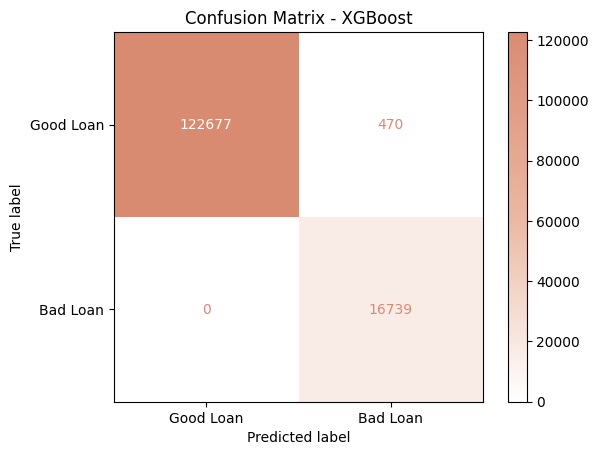

In [72]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from matplotlib.colors import LinearSegmentedColormap

colors = ["#ffffff", "#ebb7a2", "#d98b72"]
cmap_peach = LinearSegmentedColormap.from_list("custom_peach", colors)

# 1. Ambil nama dan model terbaik (urutan pertama setelah disortir tadi)
# Karena df_final_comparison disortir berdasarkan F1-Score,
# kita ambil index dari model XGBoost yang ada di posisi teratas.
best_model_tuple = tuned_models_list[2]
best_model_name = best_model_tuple[0]
best_model_obj = best_model_tuple[1]

# 2. Lakukan prediksi menggunakan X_test
y_pred_best = best_model_obj.predict(X_test)

# 3. Buat Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)

# 4. Visualisasi
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Good Loan', 'Bad Loan'])
disp.plot(cmap=cmap_peach, values_format='d')

plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()

<Figure size 1000x600 with 0 Axes>

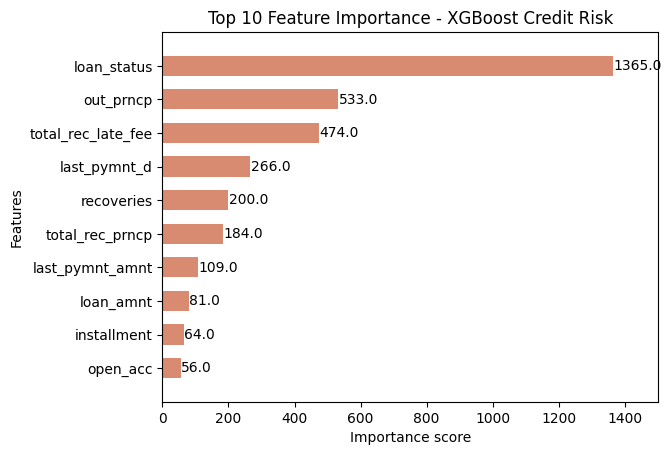

In [76]:
from xgboost import plot_importance

# Menampilkan 10 fitur paling berpengaruh menurut XGBoost
plt.figure(figsize=(10, 6))
plot_importance(best_model_obj, max_num_features=10, height=0.6, color='#d98b72')
plt.grid(False)
plt.title("Top 10 Feature Importance - XGBoost Credit Risk")
plt.show()

# Data Set

In [74]:
import joblib

# Mengambil model XGBoost terbaik dari hasil tuning sebelumnya
best_model = random_search_xgb.best_estimator_

# 1. Simpan Daftar Fitur (Sangat penting agar urutan kolom saat deploy nanti tidak tertukar)
feature_names = X_train.columns.tolist()
joblib.dump(feature_names, 'feature_names.joblib')

# 2. Simpan Scaler
joblib.dump(scaler, 'scaler.joblib')

# 3. Simpan Model
joblib.dump(best_model, 'model_credit_risk_xgb.joblib')

# 4. Simpan Data X_train (Opsional, sangat berguna jika nanti butuh data sampel untuk testing aplikasi)
joblib.dump(X_train, 'X_train.joblib')

print("✅ Semua file berhasil disimpan dengan benar untuk proyek Credit Risk!")
print(f"Total ada {len(feature_names)} fitur yang disimpan.")

✅ Semua file berhasil disimpan dengan benar untuk proyek Credit Risk!
Total ada 44 fitur yang disimpan.


In [75]:
# Mengonversi X_train menjadi file CSV
X_train.to_csv('template_bulk_upload.csv', index=False)

print("File CSV berhasil disimpan sebagai template bulk upload!")

File CSV berhasil disimpan sebagai template bulk upload!
